# Chapter 5 (extra) — Reversible CV by the Method of Lines

Honeychurch's Chapter 5 (Section 5.5, *"Solution using NDSolve"*) simulates the
reversible linear-sweep voltammogram by handing Fick's second law, the Nernstian
surface boundary condition and the bulk condition straight to Mathematica's
`NDSolve`. `NDSolve` discretises space and integrates the resulting system of
ODEs in time with an adaptive stiff solver, the **method of lines** (MOL).

This notebook reproduces that approach in Python with
`scipy.integrate.solve_ivp`, giving an **independent third route** to the
reversible CV alongside the explicit/implicit finite differences and the
semi-analytic Volterra integral already in the main chapter notebook. The point
is cross-validation: three structurally different solvers must agree on the
universal peak $\sqrt{\pi}\,\chi_p = 0.4463$ and the peak potential
$nF(E_{pc}-E^0)/RT = -1.109$.

**Method of lines.** Discretise only space on a grid $x_0=0<x_1<\dots<x_{N-1}=L$.
Each interior node becomes an ODE in time,

$$\frac{dc_j}{d\tau} = \frac{c_{j+1}-2c_j+c_{j-1}}{\Delta x^2},$$

while the surface node is algebraically pinned to the Nernstian value and the
far node is held at bulk. `solve_ivp` with a stiff method (`BDF`) then marches
the whole vector $c(\tau)$ forward. The discontinuity in the boundary slope at
the start makes the system stiff, exactly the difficulty the book flags for
`NDSolve`.

**Dimensionless variables.** We work in the same scaling as the chapter: time as
$\tau = \sigma t$ (with $\sigma = nFv/RT$), distance as $X = x\sqrt{\sigma/D}$, so
Fick's law is parameter-free, $\partial_\tau c = \partial_{XX} c$, the surface
value is $\xi/(1+\xi)$ with $\xi=\exp[nF(E-E^0)/RT]$, and the dimensionless
current group is $\sqrt{\pi}\,\chi = \partial_X c\big|_{X=0}$ (a reduction is
positive).

In [1]:
import os, sys
sys.path.insert(0, os.path.abspath('../..'))
get_ipython().run_line_magic('matplotlib', 'inline')

import math
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

from serm import echem, waveforms
from serm import ch05_potential_sweep_reversible as ch5

print("scipy solve_ivp ready; serm ch5 helpers loaded for cross-checks.")

scipy solve_ivp ready; serm ch5 helpers loaded for cross-checks.


In [2]:
from serm.sourcelinks import source_links
source_links(echem.randles_sevcik_peak_current, waveforms.dimensionless_sweep_rate,
             ch5.volterra_lsv, ch5.make_cv_grid, ch5.explicit_cv,
             ch5.dimensionless_current, ch5.potential_axis)

## Setting up the semi-discrete system

The sweep is triangular in the dimensionless overpotential
$\eta(\tau)=nF(E-E^0)/RT$: it starts at $+\,$`upper`, falls linearly to
$-\,$`lower` at the vertex $\tau=T=\text{upper}+\text{lower}$, then returns. The
surface fraction of O is $\xi/(1+\xi)$ with $\xi=e^{\eta}$.

The spatial domain is truncated at $L\approx 6\sqrt{2T}$, six diffusion lengths
of the full cycle, which is effectively semi-infinite (the bulk node never
departs from 1). We enforce the Dirichlet surface condition by overwriting
$c_0$ with its Nernstian value inside the right-hand side before computing the
Laplacian, so the boundary tracks the sweep at every adaptive time step.

In [3]:
def make_mol_solver(upper=10.0, lower=10.0, N=600, x_extent=6.0):
    """Build the dimensionless method-of-lines RHS and grid for a reversible CV.

    Returns (rhs, x, T) where ``rhs(tau, c)`` is the semi-discrete Fick system,
    ``x`` the spatial grid (dimensionless distance X) and ``T`` the vertex time.
    """
    T = upper + lower
    L = x_extent * math.sqrt(2.0 * T)        # ~6 diffusion lengths of the cycle
    x = np.linspace(0.0, L, N)
    dx = x[1] - x[0]

    def eta(tau):                            # dimensionless overpotential nF(E-E0)/RT
        return upper - tau if tau <= T else -lower + (tau - T)

    def csurf(tau):
        xi = math.exp(eta(tau))
        return xi / (1.0 + xi)               # Nernstian surface fraction of O

    inv_dx2 = 1.0 / dx**2

    def rhs(tau, c):
        c = c.copy()
        c[0] = csurf(tau)                    # pin surface to Nernst at this instant
        d = np.zeros_like(c)
        d[1:-1] = (c[2:] - 2.0 * c[1:-1] + c[:-2]) * inv_dx2
        # surface and bulk nodes are algebraic (held), so their derivative is 0
        return d

    return rhs, x, T, csurf


rhs, x, T, csurf = make_mol_solver(upper=10.0, lower=10.0, N=600)
dx = x[1] - x[0]
c0 = np.ones(x.size)
c0[0] = csurf(0.0)
print(f"N = {x.size} spatial nodes, L = {x[-1]:.2f}, dx = {dx:.4f}, vertex T = {T}")

N = 600 spatial nodes, L = 37.95, dx = 0.0634, vertex T = 20.0


## Integrating in time

`solve_ivp` with `method='BDF'` (implicit, variable-order backward differentiation,
appropriate for the stiff start) marches the concentration vector over the full
cycle $\tau\in[0,2T]$. We request a dense set of evaluation points so the current
trace is smooth. After integration we re-impose the exact surface values (they are
algebraic, not integrated) and form the dimensionless current from a one-sided
three-point surface gradient.

In [4]:
tau_eval = np.linspace(0.0, 2.0 * T, 2001)
sol = solve_ivp(rhs, [0.0, 2.0 * T], c0, method='BDF',
                t_eval=tau_eval, rtol=1e-7, atol=1e-9)
assert sol.success, sol.message
print(f"solve_ivp: {sol.message}  ({sol.t.size} output points, "
      f"{sol.nfev} RHS evals)")

cmat = sol.y.copy()
cmat[0, :] = np.array([csurf(tt) for tt in sol.t])   # exact algebraic surface

# Dimensionless current sqrt(pi)*chi = dC/dX|_0 (three-point one-sided gradient).
sqrtpi_chi = (-3.0 * cmat[0] + 4.0 * cmat[1] - cmat[2]) / (2.0 * dx)
eta_axis = np.array([10.0 - tt if tt <= T else -10.0 + (tt - T) for tt in sol.t])
fwd = sol.t <= T

chi_p = float(sqrtpi_chi[fwd].max())
eta_p = float(eta_axis[fwd][sqrtpi_chi[fwd].argmax()])
print(f"MOL peak  sqrt(pi)*chi_p = {chi_p:.5f}   (theory 0.4463)")
print(f"MOL peak  eta_pc = {eta_p:.3f} RT/nF      (theory -1.109)")

solve_ivp: The solver successfully reached the end of the integration interval.  (2001 output points, 580 RHS evals)
MOL peak  sqrt(pi)*chi_p = 0.44629   (theory 0.4463)
MOL peak  eta_pc = -1.120 RT/nF      (theory -1.109)


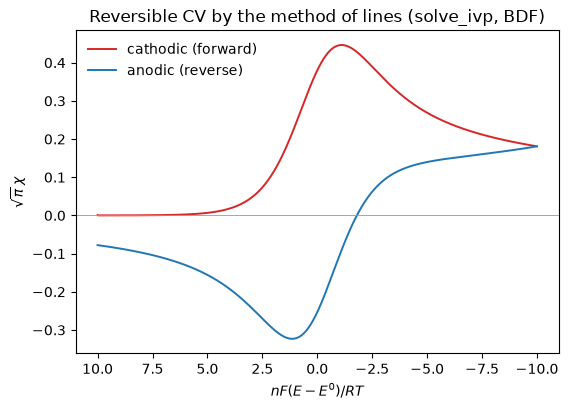

In [5]:
fig, ax = plt.subplots(figsize=(5.8, 4.2))
ax.plot(eta_axis[fwd], sqrtpi_chi[fwd], color='C3', lw=1.4, label='cathodic (forward)')
ax.plot(eta_axis[~fwd], sqrtpi_chi[~fwd], color='C0', lw=1.4, label='anodic (reverse)')
ax.axhline(0.0, color='0.6', lw=0.6)
ax.set_xlabel(r'$nF(E-E^0)/RT$')
ax.set_ylabel(r'$\sqrt{\pi}\,\chi$')
ax.set_title('Reversible CV by the method of lines (solve_ivp, BDF)')
ax.invert_xaxis()
ax.legend(frameon=False)
plt.tight_layout(); plt.show()

## Validation

We apply, strongest first, the validation tiers of the porting spec.

**Tier 1, independent closed form.** The reversible peak has the universal value
$\sqrt{\pi}\,\chi_p = 0.4463$ (the Randles–Ševčík coefficient in `serm.echem`),
and the peak potential is $nF(E_{pc}-E^0)/RT = -1.109$. The MOL solver, built
from a completely different discretisation than the finite-difference code, must
reproduce both.

**Tier 3, cross-method self-consistency.** We overlay the MOL forward sweep on
the semi-analytic Volterra integral (`ch5.volterra_lsv`) and on the explicit
finite-difference simulator (`ch5.explicit_cv`). All three independent routes
must agree across the body of the wave.

**Tier 3, spatial convergence.** Refining the number of MOL nodes drives the
peak monotonically toward 0.4463.

In [6]:
# --- Tier 1: peak value and peak potential against the closed form ---------
CHI_P, ETA_PC = 0.4463, -1.109
err_peak = abs(chi_p - CHI_P) / CHI_P
print(f"|chi_p - 0.4463|/0.4463 = {err_peak:.2e}")
assert err_peak < 1e-2, err_peak
assert abs(eta_p - ETA_PC) < 0.05, eta_p

# The dimensionless peak IS the Randles-Sevcik coefficient: rebuild a dimensional
# i_p from the MOL peak and compare to serm.echem across scan rates (sqrt(v) law).
F, A, D, c_bulk, n_el, Tk = echem.F, 1.0, 1e-5, 1e-6, 1, 298.15
max_rel = 0.0
for v in (0.01, 0.05, 0.1, 0.5):
    sigma = waveforms.dimensionless_sweep_rate(v, n_el, Tk)
    ip_mol = n_el * F * A * c_bulk * math.sqrt(sigma * D) * chi_p
    ip_rs = echem.randles_sevcik_peak_current(n_el, A, D, c_bulk, v, Tk)
    rel = abs(ip_mol - ip_rs) / ip_rs
    max_rel = max(max_rel, rel)
    print(f"v={v:5.2f} V/s: i_p(MOL)={ip_mol:.4e} A  i_p(RS)={ip_rs:.4e} A  rel={rel:.2e}")
assert max_rel < 1e-2, max_rel
print("PASS (tier 1): MOL reproduces the universal peak and the Randles-Sevcik "
      "sqrt(v) law.")

|chi_p - 0.4463|/0.4463 = 3.26e-05
v= 0.01 V/s: i_p(MOL)=8.4951e-05 A  i_p(RS)=8.4954e-05 A  rel=3.26e-05
v= 0.05 V/s: i_p(MOL)=1.8996e-04 A  i_p(RS)=1.8996e-04 A  rel=3.26e-05
v= 0.10 V/s: i_p(MOL)=2.6864e-04 A  i_p(RS)=2.6865e-04 A  rel=3.26e-05
v= 0.50 V/s: i_p(MOL)=6.0070e-04 A  i_p(RS)=6.0072e-04 A  rel=3.26e-05
PASS (tier 1): MOL reproduces the universal peak and the Randles-Sevcik sqrt(v) law.


max |MOL - Volterra| = 2.7692e-04
max |MOL - explicit FD| = 5.9889e-04
PASS (tier 3): all three independent solvers agree to < 5e-3.


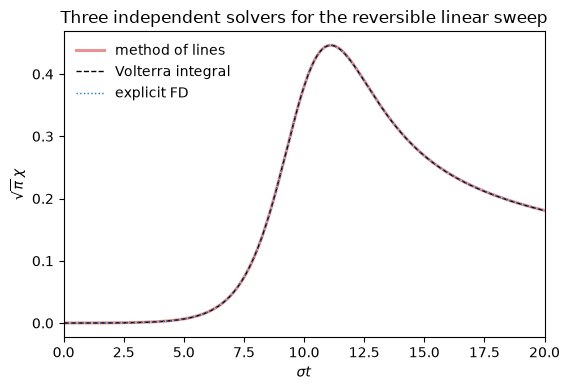

In [7]:
# --- Tier 3: agreement with the Volterra integral and the FD simulator ----
# MOL forward sweep as a function of sigma*t = upper - eta.
st_mol = 10.0 - eta_axis[fwd]
chi_mol = sqrtpi_chi[fwd]

# Semi-analytic Volterra reference (independent quadrature, init = 10).
chi_volt = ch5.volterra_lsv(st_mol, init=10.0)

# Explicit finite-difference simulator, sampled onto the same sigma*t grid.
g = ch5.make_cv_grid(0.45, 4001, lower_limit=10.0, upper_limit=10.0)
ch5.explicit_cv(g)
chi_fd_full = -ch5.dimensionless_current(g)
vtx = (g.n + 1) // 2
st_fd = g.upper_limit - ch5.potential_axis(g)[:vtx]
chi_fd_on_mol = np.interp(st_mol, st_fd, chi_fd_full[:vtx])

# Compare over the body of the wave (skip the singular start and the far tail).
mask = (st_mol > 1.0) & (st_mol < 2 * 10.0 - 1.0)
dev_volt = float(np.abs(chi_mol[mask] - chi_volt[mask]).max())
dev_fd = float(np.abs(chi_mol[mask] - chi_fd_on_mol[mask]).max())
print(f"max |MOL - Volterra| = {dev_volt:.4e}")
print(f"max |MOL - explicit FD| = {dev_fd:.4e}")
assert dev_volt < 5e-3, dev_volt
assert dev_fd < 5e-3, dev_fd
print("PASS (tier 3): all three independent solvers agree to < 5e-3.")

fig, ax = plt.subplots(figsize=(5.8, 4.0))
ax.plot(st_mol, chi_mol, color='C3', lw=2.2, alpha=0.5, label='method of lines')
ax.plot(st_mol, chi_volt, color='k', lw=1.0, ls='--', label='Volterra integral')
ax.plot(st_fd, chi_fd_full[:vtx], color='C0', lw=1.0, ls=':', label='explicit FD')
ax.set_xlabel(r'$\sigma t$'); ax.set_ylabel(r'$\sqrt{\pi}\,\chi$')
ax.set_xlim(0, 20); ax.legend(frameon=False)
ax.set_title('Three independent solvers for the reversible linear sweep')
plt.tight_layout(); plt.show()

In [8]:
# --- Tier 3: spatial convergence of the MOL peak --------------------------
peaks = []
for N in (150, 300, 600, 1200):
    rhsN, xN, TN, csurfN = make_mol_solver(upper=10.0, lower=10.0, N=N)
    dxN = xN[1] - xN[0]
    c0N = np.ones(N); c0N[0] = csurfN(0.0)
    solN = solve_ivp(rhsN, [0.0, 2.0 * TN], c0N, method='BDF',
                     t_eval=np.linspace(0.0, 2 * TN, 2001), rtol=1e-7, atol=1e-9)
    cN = solN.y.copy(); cN[0] = np.array([csurfN(tt) for tt in solN.t])
    spxN = (-3.0 * cN[0] + 4.0 * cN[1] - cN[2]) / (2.0 * dxN)
    fwdN = solN.t <= TN
    pk = float(spxN[fwdN].max())
    peaks.append(pk)
    print(f"N={N:5d}: chi_p = {pk:.5f}  |err| = {abs(pk - 0.4463):.2e}")

errs = [abs(p - 0.4463) for p in peaks]
assert errs[-1] < errs[0], (errs[0], errs[-1])
print("PASS (tier 3): MOL peak converges toward 0.4463 under spatial refinement.")

N=  150: chi_p = 0.44596  |err| = 3.43e-04


N=  300: chi_p = 0.44625  |err| = 5.05e-05


N=  600: chi_p = 0.44629  |err| = 1.46e-05


N= 1200: chi_p = 0.44629  |err| = 9.45e-06
PASS (tier 3): MOL peak converges toward 0.4463 under spatial refinement.


## Summary

The method of lines (discretise space, integrate the resulting stiff ODE system
in time with `scipy.integrate.solve_ivp` (`BDF`)) reproduces Mathematica's
`NDSolve` route to the reversible cyclic voltammogram. It is structurally
independent of the explicit/implicit finite-difference simulators and of the
semi-analytic Volterra integral, yet lands on the same universal results:

- peak $\sqrt{\pi}\,\chi_p \approx 0.4463$ and peak potential
  $nF(E_{pc}-E^0)/RT \approx -1.109$ (validated against the closed form and the
  Randles–Ševčík $\sqrt{v}$ law);
- forward-sweep agreement with both the Volterra integral and the explicit FD
  simulator to $<5\times10^{-3}$;
- monotone convergence of the peak under spatial refinement.

This gives the chapter a genuine **three-way cross-check** of the reversible
voltammogram.

<!-- nav-footer -->

---

[← Chapter 5 — Potential Sweep Methods: the Reversible Voltammogram](../05_potential_sweep_reversible.ipynb)

[Contents (README)](../../README.md)